In [5]:
# Download HURDAT2 Atlantic hurricane database from NOAA (auto-detects current filename)
import urllib.request
import re
from pathlib import Path

# Scrape the current HURDAT2 URL from the NOAA data archive page
noaa_page = "https://www.nhc.noaa.gov/data/"
with urllib.request.urlopen(noaa_page) as response:
    html = response.read().decode("utf-8")

# Match both absolute and relative URLs
match = re.search(r'href="([^"]*hurdat2-\d{4}-\d{4}-\d+\.txt)"', html)
if not match:
    raise RuntimeError("Could not find HURDAT2 download URL on NOAA page. Check https://www.nhc.noaa.gov/data/ manually.")

url = match.group(1)
# Handle relative URLs
if url.startswith("/"):
    url = "https://www.nhc.noaa.gov" + url
hurdat2_url = url
hurdat2_file = Path("hurdat2_atlantic.txt")

print(f"Found URL: {hurdat2_url}")

if not hurdat2_file.exists():
    print(f"Downloading HURDAT2...")
    urllib.request.urlretrieve(hurdat2_url, hurdat2_file)
    print(f"Done: {hurdat2_file.stat().st_size / 1e6:.1f} MB")
else:
    print(f"HURDAT2 already exists: {hurdat2_file}")

Found URL: https://www.nhc.noaa.gov/data/hurdat/hurdat2-1851-2025-02272026.txt
Done: 7.1 MB


In [6]:
from pathlib import Path
import os

print("Working directory:", os.getcwd())
print("Files:", list(Path(".").iterdir()))

file = Path("hurdat2_atlantic.txt")

with open(file) as f:
    for i in range(10):
        print(f.readline().strip())

Working directory: /home/ec2-user/projects/FCN4AWS
Files: [PosixPath('.git'), PosixPath('.gitignore'), PosixPath('FCNv2_Visualizations.ipynb'), PosixPath('batch_runner.py'), PosixPath('noaa_historical_tracks_analysis.ipynb'), PosixPath('.ipynb_checkpoints'), PosixPath('README.md'), PosixPath('requirements.txt'), PosixPath('hurdat2_atlantic.txt')]
AL011851,            UNNAMED,     14,
18510625, 0000,  , HU, 28.0N,  94.8W,  80, -999, -999, -999, -999, -999, -999, -999, -999, -999, -999, -999, -999, -999, -999
18510625, 0600,  , HU, 28.0N,  95.4W,  80, -999, -999, -999, -999, -999, -999, -999, -999, -999, -999, -999, -999, -999, -999
18510625, 1200,  , HU, 28.0N,  96.0W,  80, -999, -999, -999, -999, -999, -999, -999, -999, -999, -999, -999, -999, -999, -999
18510625, 1800,  , HU, 28.1N,  96.5W,  80, -999, -999, -999, -999, -999, -999, -999, -999, -999, -999, -999, -999, -999, -999
18510625, 2100, L, HU, 28.2N,  96.8W,  80, -999, -999, -999, -999, -999, -999, -999, -999, -999, -999, -999, 

In [7]:
from pathlib import Path
import pandas as pd
import numpy as np

file = Path("hurdat2_atlantic.txt")
print(file.exists(), file)

def parse_lat(lat_str):
    lat_str = lat_str.strip()
    value = float(lat_str[:-1])
    hemi = lat_str[-1].upper()
    return value if hemi == "N" else -value

def parse_lon(lon_str):
    lon_str = lon_str.strip()
    value = float(lon_str[:-1])
    hemi = lon_str[-1].upper()
    return value if hemi == "E" else -value

def clean_numeric(value):
    value = str(value).strip()
    if value in {"", "-999", "-999.0"}:
        return np.nan
    try:
        return float(value)
    except ValueError:
        return np.nan

True hurdat2_atlantic.txt


In [8]:
rows = []

current_storm_id = None
current_storm_name = None
current_num_entries = None

with open(file, "r") as f:
    for line in f:
        parts = [p.strip() for p in line.strip().split(",")]

        # Skip empty lines
        if not parts or all(p == "" for p in parts):
            continue

        # Header row: e.g. AL011851, UNNAMED, 14,
        # Observation rows start with an 8-digit date like 18510625
        first_token = parts[0]

        is_observation = first_token.isdigit() and len(first_token) == 8

        if not is_observation:
            current_storm_id = parts[0]
            current_storm_name = parts[1] if len(parts) > 1 else None
            current_num_entries = parts[2] if len(parts) > 2 else None
            continue

        # Observation row
        row = {
            "storm_id": current_storm_id,
            "storm_name": current_storm_name,
            "num_entries": current_num_entries,
            "date_str": parts[0] if len(parts) > 0 else None,
            "time_str": parts[1] if len(parts) > 1 else None,
            "record_identifier": parts[2] if len(parts) > 2 else None,
            "status": parts[3] if len(parts) > 3 else None,
            "lat_raw": parts[4] if len(parts) > 4 else None,
            "lon_raw": parts[5] if len(parts) > 5 else None,
            "max_wind_kt": parts[6] if len(parts) > 6 else None,
            "min_pressure_mb": parts[7] if len(parts) > 7 else None,
        }

        rows.append(row)

df = pd.DataFrame(rows)
print(df.shape)
df.head()

(55605, 11)


,storm_id,storm_name,num_entries,date_str,time_str,record_identifier,status,lat_raw,lon_raw,max_wind_kt,min_pressure_mb
0,AL011851,UNNAMED,14,18510625,0000,,HU,28.0N,94.8W,80,-999
1,AL011851,UNNAMED,14,18510625,0600,,HU,28.0N,95.4W,80,-999
2,AL011851,UNNAMED,14,18510625,1200,,HU,28.0N,96.0W,80,-999
3,AL011851,UNNAMED,14,18510625,1800,,HU,28.1N,96.5W,80,-999
4,AL011851,UNNAMED,14,18510625,2100,L,HU,28.2N,96.8W,80,-999


In [9]:
df["lat"] = df["lat_raw"].apply(parse_lat)
df["lon"] = df["lon_raw"].apply(parse_lon)

df["max_wind_kt"] = df["max_wind_kt"].apply(clean_numeric)
df["min_pressure_mb"] = df["min_pressure_mb"].apply(clean_numeric)

df["num_entries"] = pd.to_numeric(df["num_entries"], errors="coerce")

In [10]:
df["date_str"] = df["date_str"].astype(str).str.zfill(8)
df["time_str"] = df["time_str"].astype(str).str.zfill(4)

df["datetime"] = pd.to_datetime(
    df["date_str"] + df["time_str"],
    format="%Y%m%d%H%M",
    errors="coerce"
)

df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["day"] = df["datetime"].dt.day
df["hour"] = df["datetime"].dt.hour

In [11]:
text_cols = ["storm_id", "storm_name", "record_identifier", "status"]

for col in text_cols:
    df[col] = df[col].astype("string").str.strip()

df["storm_name"] = df["storm_name"].str.upper()
df["record_identifier"] = df["record_identifier"].replace({"": pd.NA})

In [12]:
print(df.shape)
print(df.dtypes)
df.head(10)

(55605, 18)
storm_id             string[python]
storm_name           string[python]
num_entries                   int64
date_str                     object
time_str                     object
record_identifier    string[python]
status               string[python]
lat_raw                      object
lon_raw                      object
max_wind_kt                 float64
min_pressure_mb             float64
lat                         float64
lon                         float64
datetime             datetime64[ns]
year                          int32
month                         int32
day                           int32
hour                          int32
dtype: object


,storm_id,storm_name,num_entries,date_str,time_str,record_identifier,status,lat_raw,lon_raw,max_wind_kt,min_pressure_mb,lat,lon,datetime,year,month,day,hour
0,AL011851,UNNAMED,14,18510625,0000,<NA>,HU,28.0N,94.8W,80.0,NaN,28.0,-94.8,1851-06-25 00:00:00,1851,6,25,0
1,AL011851,UNNAMED,14,18510625,0600,<NA>,HU,28.0N,95.4W,80.0,NaN,28.0,-95.4,1851-06-25 06:00:00,1851,6,25,6
2,AL011851,UNNAMED,14,18510625,1200,<NA>,HU,28.0N,96.0W,80.0,NaN,28.0,-96.0,1851-06-25 12:00:00,1851,6,25,12
3,AL011851,UNNAMED,14,18510625,1800,<NA>,HU,28.1N,96.5W,80.0,NaN,28.1,-96.5,1851-06-25 18:00:00,1851,6,25,18
4,AL011851,UNNAMED,14,18510625,2100,L,HU,28.2N,96.8W,80.0,NaN,28.2,-96.8,1851-06-25 21:00:00,1851,6,25,21
5,AL011851,UNNAMED,14,18510626,0000,<NA>,HU,28.2N,97.0W,70.0,NaN,28.2,-97.0,1851-06-26 00:00:00,1851,6,26,0
6,AL011851,UNNAMED,14,18510626,0600,<NA>,TS,28.3N,97.6W,60.0,NaN,28.3,-97.6,1851-06-26 06:00:00,1851,6,26,6
7,AL011851,UNNAMED,14,18510626,1200,<NA>,TS,28.4N,98.3W,60.0,NaN,28.4,-98.3,1851-06-26 12:00:00,1851,6,26,12
8,AL011851,UNNAMED,14,18510626,1800,<NA>,TS,28.6N,98.9W,50.0,NaN,28.6,-98.9,1851-06-26 18:00:00,1851,6,26,18
9,AL011851,UNNAMED,14,18510627,0000,<NA>,TS,29.0N,99.4W,50.0,NaN,29.0,-99.4,1851-06-27 00:00:00,1851,6,27,0


In [13]:
print("Unique storms:", df["storm_id"].nunique())
print("Date range:", df["datetime"].min(), "to", df["datetime"].max())
print("Latitude range:", df["lat"].min(), "to", df["lat"].max())
print("Longitude range:", df["lon"].min(), "to", df["lon"].max())

print("\nMissing datetime rows:", df["datetime"].isna().sum())
print("Missing lat rows:", df["lat"].isna().sum())
print("Missing lon rows:", df["lon"].isna().sum())

Unique storms: 2004
Date range: 1851-06-25 00:00:00 to 2025-11-01 06:00:00
Latitude range: 7.0 to 83.0
Longitude range: -136.9 to 63.0

Missing datetime rows: 0
Missing lat rows: 0
Missing lon rows: 0


In [14]:
comparison_df = df[
    [
        "storm_id",
        "storm_name",
        "datetime",
        "year",
        "month",
        "day",
        "hour",
        "record_identifier",
        "status",
        "lat",
        "lon",
        "max_wind_kt",
        "min_pressure_mb",
    ]
].copy()

comparison_df = comparison_df.sort_values(
    ["storm_id", "datetime"]
).reset_index(drop=True)

comparison_df.head(10)

,storm_id,storm_name,datetime,year,month,day,hour,record_identifier,status,lat,lon,max_wind_kt,min_pressure_mb
0,AL011851,UNNAMED,1851-06-25 00:00:00,1851,6,25,0,<NA>,HU,28.0,-94.8,80.0,NaN
1,AL011851,UNNAMED,1851-06-25 06:00:00,1851,6,25,6,<NA>,HU,28.0,-95.4,80.0,NaN
2,AL011851,UNNAMED,1851-06-25 12:00:00,1851,6,25,12,<NA>,HU,28.0,-96.0,80.0,NaN
3,AL011851,UNNAMED,1851-06-25 18:00:00,1851,6,25,18,<NA>,HU,28.1,-96.5,80.0,NaN
4,AL011851,UNNAMED,1851-06-25 21:00:00,1851,6,25,21,L,HU,28.2,-96.8,80.0,NaN
5,AL011851,UNNAMED,1851-06-26 00:00:00,1851,6,26,0,<NA>,HU,28.2,-97.0,70.0,NaN
6,AL011851,UNNAMED,1851-06-26 06:00:00,1851,6,26,6,<NA>,TS,28.3,-97.6,60.0,NaN
7,AL011851,UNNAMED,1851-06-26 12:00:00,1851,6,26,12,<NA>,TS,28.4,-98.3,60.0,NaN
8,AL011851,UNNAMED,1851-06-26 18:00:00,1851,6,26,18,<NA>,TS,28.6,-98.9,50.0,NaN
9,AL011851,UNNAMED,1851-06-27 00:00:00,1851,6,27,0,<NA>,TS,29.0,-99.4,50.0,NaN


In [15]:
output_file = Path("noaa_tracks_clean.csv")
comparison_df.to_csv(output_file, index=False)
print("Saved:", output_file.resolve())

Saved: /home/ec2-user/projects/FCN4AWS/noaa_tracks_clean.csv


In [16]:
storm_starts = (
    comparison_df
    .sort_values("datetime")
    .groupby("storm_id")
    .first()
    .reset_index()
)

storm_starts = storm_starts[
    ["storm_id", "storm_name", "datetime", "lat", "lon"]
]

storm_starts = storm_starts.rename(columns={
    "datetime": "start_datetime",
    "lat": "start_lat",
    "lon": "start_lon"
})

storm_starts.head()

storm_starts.to_csv("noaa_storm_starts.csv", index=False)

In [19]:
# How many storms are we actually talking about?
hurdat = pd.read_csv("/home/ec2-user/projects/FCN4AWS/noaa_tracks_clean.csv",
                     parse_dates=["datetime"])

storm_starts = pd.read_csv("/home/ec2-user/projects/FCN4AWS/noaa_storm_starts.csv",
                           parse_dates=["start_datetime"])

# Filter to 1980+, Atlantic basin, named storms only (HU or TS status at some point)
modern = storm_starts[storm_starts["start_datetime"].dt.year >= 1980].copy()

# Only storms that reached at least TS strength
ts_storms = hurdat[hurdat["status"].isin(["HU","TS"])]["storm_id"].unique()
modern = modern[modern["storm_id"].isin(ts_storms)]

print(f"Total storms 1980+:        {len(modern)}")
print(f"Year range:                {modern['start_datetime'].dt.year.min()} - {modern['start_datetime'].dt.year.max()}")
print(f"\nAt 3 min/forecast:         {len(modern) * 3 / 60:.1f} hours total GPU time")
print(f"At ~200MB ERA5/download:   {len(modern) * 200 / 1000:.1f} GB CDS data")
print(f"\nStorms per year (avg):     {len(modern) / (2024-1980):.1f}")
modern["year"] = modern["start_datetime"].dt.year
print("\nStorms per decade:")
print(modern.groupby(modern["year"] // 10 * 10).size())

Total storms 1980+:        609
Year range:                1980 - 2025

At 3 min/forecast:         30.4 hours total GPU time
At ~200MB ERA5/download:   121.8 GB CDS data

Storms per year (avg):     13.8

Storms per decade:
year
1980     90
1990    108
2000    147
2010    152
2020    112
dtype: int64


In [1]:
# Run from terminal instead — see README Phase 2, Step 2
# python3 batch_runner.py 2>&1 | tee batch_run.log
print("Run batch_runner.py from the terminal, not this notebook.")
print("See README Phase 2, Step 2 for instructions.")

Run batch_runner.py from the terminal, not this notebook.
See README Phase 2, Step 2 for instructions.


In [ ]:
# Run Batch FCNv2 Inference ────────────────────────────────────────────────────
#
# batch_runner.py is a long-running process (est. 30+ hrs for full sample).
# It should be run from the terminal to avoid disconnection issues, NOT from this notebook cell.
# Running from the notebook risks losing the entire run if the kernel dies
# or the browser disconnects.
#
# ── TERMINAL WORKFLOW ─────────────────────────────────────────────────────────
#
# 1. Open a terminal tab in JupyterLab (File → New → Terminal)
#
# 2. Launch the batch runner in the background with nohup so it survives
#    SSH disconnects and browser closes:
#       nohup python3 batch_runner.py > batch_run.log 2>&1 &
#       echo $!
#    The number printed is the process ID (PID) — save it if you want to
#    kill the run early with: kill <PID>
#
# 3. Monitor progress at any time (from any terminal session):
#       tail -f ~/projects/FCN4AWS/batch_run.log
#    Press Ctrl+C to stop watching the log (does NOT stop the run).
#
# 4. Check if it is still running:
#       ps aux | grep batch_runner.py
#
# 5. When complete, results are saved to:
#       fcnv2_batch_results/batch_results.csv   ← summary (one row per storm)
#       fcnv2_batch_tracks/<storm_id>_fcnv2_track.csv  ← per-storm tracks
#
# 6. Once complete, proceed to FCNv2_Visualizations.ipynb
# ─────────────────────────────────────────────────────────────────────────────

In [1]:
# Map out the comparisions between NOAA and FCNv2 data points

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
from pathlib import Path

BASE_DIR    = Path("/home/ec2-user/projects/FCN4AWS")
TRACKS_DIR  = BASE_DIR / "fcnv2_batch_tracks"
RESULTS_DIR = BASE_DIR / "fcnv2_batch_results"

# Load everything fresh
results_df = pd.read_csv(RESULTS_DIR / "batch_results.csv")
storm_ids  = results_df["storm_id"].tolist()

hurdat = pd.read_csv(
    BASE_DIR / "noaa_tracks_clean.csv",
    parse_dates=["datetime"]
)

track_files = sorted(TRACKS_DIR.glob("*_fcnv2_track.csv"))
all_fcnv2 = [pd.read_csv(f, parse_dates=["valid_time"]) for f in track_files]

print(f"Storms: {len(storm_ids)} | Tracks loaded: {len(all_fcnv2)}")
print(results_df[["storm_name","year","category","mean_error_km"]].to_string())

Storms: 28 | Tracks loaded: 28
   storm_name  year category  mean_error_km
0       CESAR  1984       TS     375.255960
1      DENNIS  1987       TS     313.017357
2     ALBERTO  1982     Cat1     188.883735
3         ANA  1997       TS     248.728939
4        ALEX  1998       TS     354.489054
5   JOSEPHINE  1990     Cat1     339.833711
6     MICHAEL  2000     Cat2     423.778562
7       ERIKA  2009       TS     182.234071
8       TAMMY  2005       TS     305.104084
9       CINDY  2005     Cat1     246.079694
10       LISA  2004     Cat1     409.156194
11      HENRI  2015       TS      89.195080
12       RINA  2017       TS     246.237827
13      JULIA  2010     Cat4     194.097867
14      JOYCE  2012       TS     155.051565
15   PHILIPPE  2011     Cat1     318.629966
16      HANNA  2020     Cat1     107.296282
17      LAURA  2020     Cat4     346.779953
18     ANDREA  2025       TS     391.777757
19        IAN  2022     Cat5     232.588234
20     GASTON  2022       TS     328.454647
2

/opt/pytorch/lib64/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/pytorch/lib64/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/opt/pytorch/lib64/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


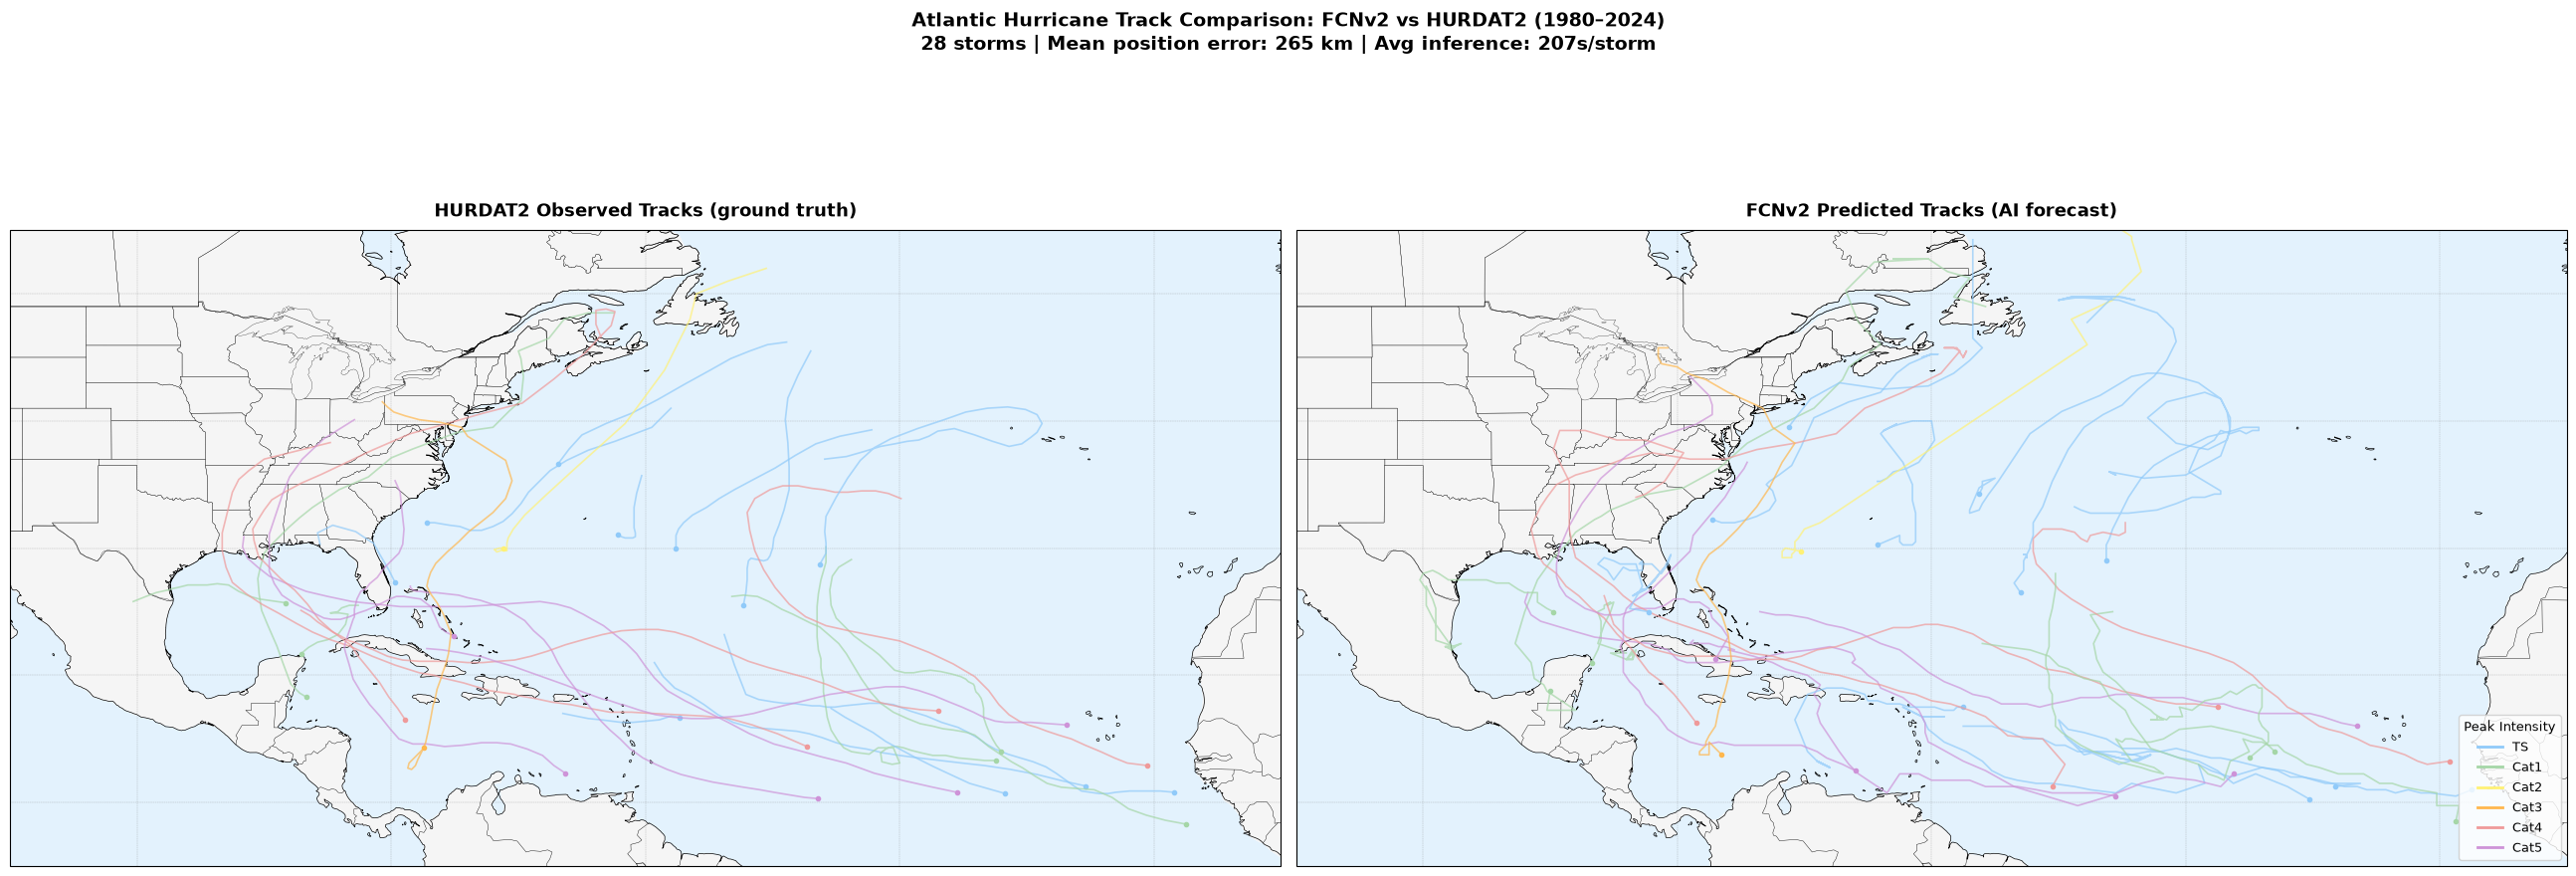

Saved to /home/ec2-user/projects/FCN4AWS/spaghetti_fcnv2_vs_hurdat2.png


In [2]:
# ── Category colors ───────────────────────────────────────────────────────────
cat_colors = {
    "TS":   "#90caf9",
    "Cat1": "#a5d6a7",
    "Cat2": "#fff176",
    "Cat3": "#ffb74d",
    "Cat4": "#ef9a9a",
    "Cat5": "#ce93d8"
}

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 2, figsize=(26, 10),
                         subplot_kw={'projection': proj})

for ax in axes:
    ax.set_extent([-110, -10, 5, 55], crs=proj)
    ax.coastlines(resolution='50m', linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.3)
    ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.2)
    ax.add_feature(cfeature.LAND, facecolor='#f5f5f5')
    ax.add_feature(cfeature.OCEAN, facecolor='#e3f2fd')
    gl = ax.gridlines(draw_labels=False, linestyle='--',
                  linewidth=0.3, color='gray', alpha=0.6)

# ── Left: HURDAT2 observed tracks ─────────────────────────────────────────────
axes[0].set_title("HURDAT2 Observed Tracks (ground truth)", 
                   fontsize=13, fontweight='bold', pad=10)

for sid in storm_ids:
    row = results_df[results_df["storm_id"] == sid].iloc[0]
    cat = row["category"]
    color = cat_colors.get(cat, "gray")
    
    storm = hurdat[hurdat["storm_id"] == sid].sort_values("datetime")
    # Trim to forecast window (240hr from genesis)
    start = storm["datetime"].min()
    storm = storm[storm["datetime"] <= start + pd.Timedelta(hours=240)]
    
    axes[0].plot(storm["lon"], storm["lat"],
                 '-', linewidth=1.2, color=color, alpha=0.7,
                 transform=proj)
    # Mark genesis
    axes[0].plot(storm["lon"].iloc[0], storm["lat"].iloc[0],
                 'o', markersize=3, color=color, transform=proj)

# ── Right: FCNv2 predicted tracks ─────────────────────────────────────────────
axes[1].set_title("FCNv2 Predicted Tracks (AI forecast)",
                   fontsize=13, fontweight='bold', pad=10)

for df in all_fcnv2:
    sid = df["storm_id"].iloc[0]
    if sid not in storm_ids:
        continue
    row = results_df[results_df["storm_id"] == sid].iloc[0]
    cat = row["category"]
    color = cat_colors.get(cat, "gray")
    
    axes[1].plot(df["lon"], df["lat"],
                 '-', linewidth=1.2, color=color, alpha=0.7,
                 transform=proj)
    axes[1].plot(df["lon"].iloc[0], df["lat"].iloc[0],
                 'o', markersize=3, color=color, transform=proj)

# ── Legend ────────────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=cat_colors[c], linewidth=2, label=c)
    for c in ["TS","Cat1","Cat2","Cat3","Cat4","Cat5"]
]
axes[1].legend(handles=legend_elements, loc='lower right',
               fontsize=9, title="Peak Intensity", title_fontsize=9)

plt.suptitle("Atlantic Hurricane Track Comparison: FCNv2 vs HURDAT2 (1980–2024)\n"
             f"28 storms | Mean position error: {results_df['mean_error_km'].mean():.0f} km | "
             f"Avg inference: 207s/storm",
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
out = BASE_DIR / "spaghetti_fcnv2_vs_hurdat2.png"
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {out}")

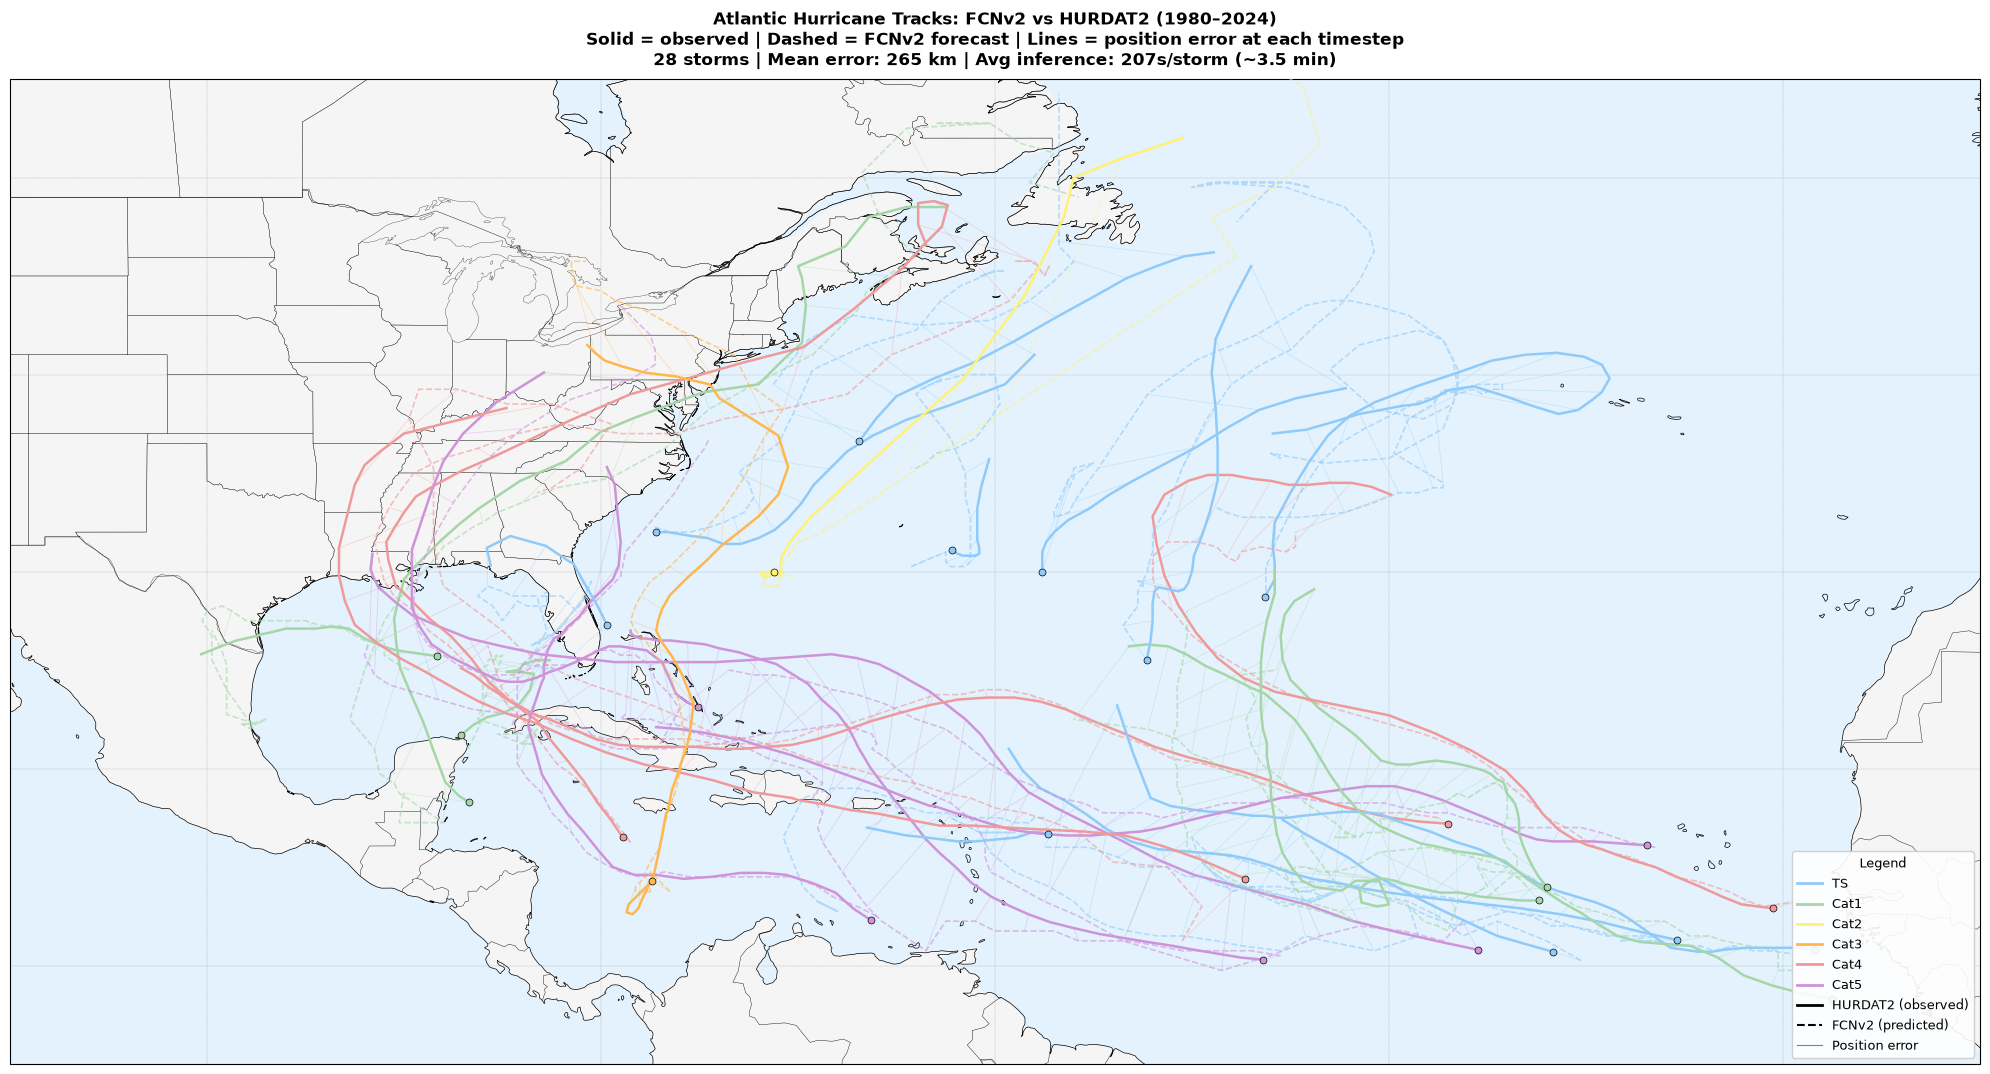

Saved to /home/ec2-user/projects/FCN4AWS/spaghetti_overlay_error_lines.png


In [3]:
import math

proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(20, 12), subplot_kw={'projection': proj})

ax.set_extent([-110, -10, 5, 55], crs=proj)
ax.coastlines(resolution='50m', linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.add_feature(cfeature.STATES.with_scale('50m'), linewidth=0.2)
ax.add_feature(cfeature.LAND, facecolor='#f5f5f5')
ax.add_feature(cfeature.OCEAN, facecolor='#e3f2fd')
gl = ax.gridlines(draw_labels=False, linestyle='--',
                  linewidth=0.3, color='gray', alpha=0.6)

for fcnv2_df in all_fcnv2:
    sid = fcnv2_df["storm_id"].iloc[0]
    if sid not in storm_ids:
        continue

    row = results_df[results_df["storm_id"] == sid].iloc[0]
    cat = row["category"]
    color = cat_colors.get(cat, "gray")

    # NOAA ground truth for this storm trimmed to forecast window
    noaa = hurdat[hurdat["storm_id"] == sid].sort_values("datetime").copy()
    start = noaa["datetime"].min()
    noaa = noaa[noaa["datetime"] <= start + pd.Timedelta(hours=240)]

    # FCNv2 track
    fcn = fcnv2_df.sort_values("valid_time").copy()

    # ── Draw NOAA track (solid, full opacity) ────────────────────────────────
    ax.plot(noaa["lon"], noaa["lat"],
            '-', linewidth=1.8, color=color, alpha=1.0,
            transform=proj, zorder=3)
    ax.plot(noaa["lon"].iloc[0], noaa["lat"].iloc[0],
            'o', markersize=5, color=color, transform=proj,
            zorder=4, markeredgecolor='black', markeredgewidth=0.5)

    # ── Draw FCNv2 track (dashed, slightly transparent) ──────────────────────
    ax.plot(fcn["lon"], fcn["lat"],
            '--', linewidth=1.2, color=color, alpha=0.6,
            transform=proj, zorder=3)

    # ── Draw error lines at matched timesteps ────────────────────────────────
    fcn["valid_time"] = pd.to_datetime(fcn["valid_time"])
    noaa["valid_time"] = noaa["datetime"]
    merged = pd.merge(
        fcn[["valid_time","lat","lon"]],
        noaa[["valid_time","lat","lon"]],
        on="valid_time", suffixes=("_fcn","_noaa")
    )

    # Only draw every other timestep to avoid clutter
    for _, r in merged.iloc[::2].iterrows():
        ax.plot([r.lon_noaa, r.lon_fcn],
                [r.lat_noaa, r.lat_fcn],
                '-', linewidth=0.6, color=color,
                alpha=0.35, transform=proj, zorder=2)

# ── Legend ────────────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color=cat_colors[c], linewidth=2, label=c)
    for c in ["TS","Cat1","Cat2","Cat3","Cat4","Cat5"]
] + [
    Line2D([0], [0], color='black', linewidth=2, linestyle='-',  label='HURDAT2 (observed)'),
    Line2D([0], [0], color='black', linewidth=1.5, linestyle='--', label='FCNv2 (predicted)'),
    Line2D([0], [0], color='gray',  linewidth=0.8, linestyle='-',  label='Position error'),
]

ax.legend(handles=legend_elements, loc='lower right',
          fontsize=9, title="Legend", title_fontsize=9,
          framealpha=0.9)

ax.set_title(
    "Atlantic Hurricane Tracks: FCNv2 vs HURDAT2 (1980–2024)\n"
    "Solid = observed | Dashed = FCNv2 forecast | Lines = position error at each timestep\n"
    f"28 storms | Mean error: {results_df['mean_error_km'].mean():.0f} km | "
    f"Avg inference: 207s/storm (~3.5 min)",
    fontsize=12, fontweight='bold', pad=10
)

plt.tight_layout()
out = BASE_DIR / "spaghetti_overlay_error_lines.png"
plt.savefig(out, dpi=180, bbox_inches='tight')
plt.show()
print(f"Saved to {out}")

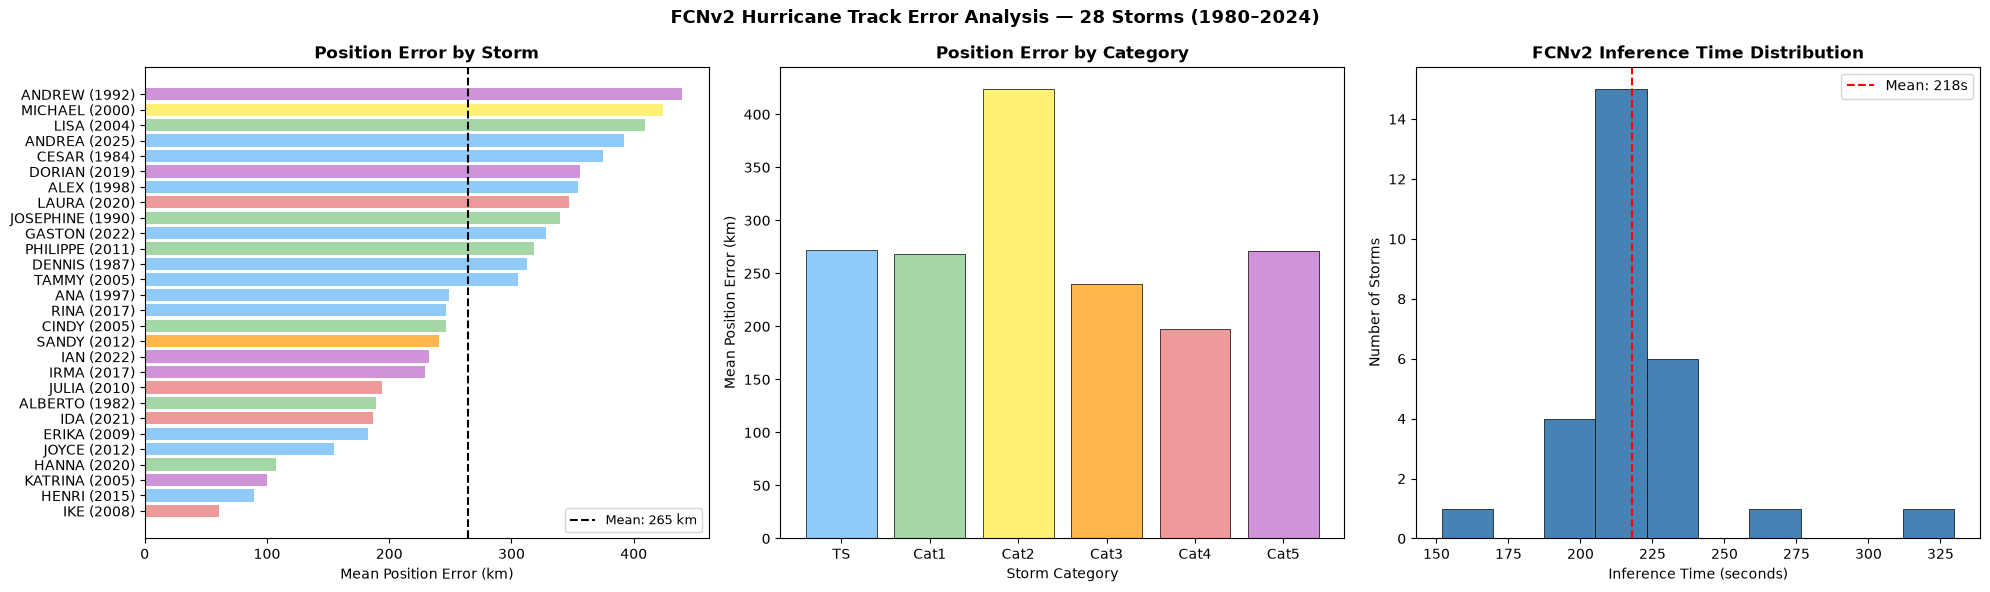

Saved to /home/ec2-user/projects/FCN4AWS/error_analysis.png


In [4]:
# ── Error summary by category ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Mean error by storm
results_sorted = results_df.sort_values("mean_error_km")
colors = [cat_colors.get(c, "gray") for c in results_sorted["category"]]
axes[0].barh(results_sorted["storm_name"] + " (" + results_sorted["year"].astype(str) + ")",
             results_sorted["mean_error_km"], color=colors)
axes[0].axvline(results_df["mean_error_km"].mean(), color='black',
                linestyle='--', label=f'Mean: {results_df["mean_error_km"].mean():.0f} km')
axes[0].set_xlabel("Mean Position Error (km)")
axes[0].set_title("Position Error by Storm", fontweight='bold')
axes[0].legend(fontsize=9)

# Error by category
cat_order = ["TS","Cat1","Cat2","Cat3","Cat4","Cat5"]
cat_means = results_df.groupby("category")["mean_error_km"].mean().reindex(
    [c for c in cat_order if c in results_df["category"].values])
axes[1].bar(cat_means.index, cat_means.values,
            color=[cat_colors[c] for c in cat_means.index],
            edgecolor='black', linewidth=0.5)
axes[1].set_xlabel("Storm Category")
axes[1].set_ylabel("Mean Position Error (km)")
axes[1].set_title("Position Error by Category", fontweight='bold')

# Inference time distribution
axes[2].hist(results_df["inference_sec"], bins=10,
             color='steelblue', edgecolor='black', linewidth=0.5)
axes[2].axvline(results_df["inference_sec"].mean(), color='red',
                linestyle='--', label=f'Mean: {results_df["inference_sec"].mean():.0f}s')
axes[2].set_xlabel("Inference Time (seconds)")
axes[2].set_ylabel("Number of Storms")
axes[2].set_title("FCNv2 Inference Time Distribution", fontweight='bold')
axes[2].legend()

plt.suptitle("FCNv2 Hurricane Track Error Analysis — 28 Storms (1980–2024)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
out2 = BASE_DIR / "error_analysis.png"
plt.savefig(out2, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {out2}")